# BANK CUSTOMER CHURN PREDICTION

**Import libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

import warnings 
warnings.filterwarnings('ignore')

# LOAD DATASET

In [3]:
df = pd.read_csv(r"C:\Users\hp\Downloads\bank_churn_dataset.csv")
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,Exited
0,491.287210,France,Female,42,10.0,40283.570765,2.0,1
1,478.397577,Spain,Female,41,10.0,36208.678494,2.0,1
2,450.130705,France,Female,42,10.0,41038.442691,2.0,1
3,458.097294,France,Female,39,10.0,42715.149282,2.0,1
4,537.984872,Spain,Female,43,12.0,37529.233126,2.0,1
...,...,...,...,...,...,...,...,...
4995,471.033062,France,Female,36,8.0,32155.174846,2.0,0
4996,468.049651,Germany,Male,44,12.0,43157.052897,3.0,1
4997,494.840498,Spain,Male,43,12.0,54264.551005,2.0,1
4998,494.872967,Spain,Female,40,9.0,40040.180947,3.0,1


# Preprocessing

In [4]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,Exited
0,491.287210,France,Female,42,10.0,40283.570765,2.0,1
1,478.397577,Spain,Female,41,10.0,36208.678494,2.0,1
2,450.130705,France,Female,42,10.0,41038.442691,2.0,1
3,458.097294,France,Female,39,10.0,42715.149282,2.0,1
4,537.984872,Spain,Female,43,12.0,37529.233126,2.0,1


In [5]:
df.tail()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,Exited
4995,471.033062,France,Female,36,8.0,32155.174846,2.0,0
4996,468.049651,Germany,Male,44,12.0,43157.052897,3.0,1
4997,494.840498,Spain,Male,43,12.0,54264.551005,2.0,1
4998,494.872967,Spain,Female,40,9.0,40040.180947,3.0,1
4999,475.331654,Spain,Female,38,9.0,29959.672010,1.0,1


In [6]:
df.shape

(5000, 8)

In [7]:
df.columns

Index(['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance',
       'NumOfProducts', 'Exited'],
      dtype='object')

In [8]:
df.info()  # summery

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CreditScore    5000 non-null   float64
 1   Geography      5000 non-null   object 
 2   Gender         5000 non-null   object 
 3   Age            5000 non-null   int64  
 4   Tenure         5000 non-null   float64
 5   Balance        5000 non-null   float64
 6   NumOfProducts  5000 non-null   float64
 7   Exited         5000 non-null   int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 312.6+ KB


In [9]:
df.describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,Exited
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,467.566983,38.988600,9.752400,35117.749650,1.973400,0.493000
std,130.554755,10.598327,2.863203,10844.929004,0.760268,0.500001
min,110.327992,18.000000,2.000000,5558.363233,1.000000,0.000000
25%,378.329484,32.000000,8.000000,27883.259750,1.000000,0.000000
50%,449.019986,37.000000,9.000000,33884.622519,2.000000,0.000000
75%,531.567479,44.000000,11.000000,40988.270255,2.000000,1.000000
max,1043.560368,88.000000,23.000000,84888.511718,5.000000,1.000000


In [10]:
df.Geography.value_counts()

Geography
France     2506
Germany    1255
Spain      1239
Name: count, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
c=df.select_dtypes(include="number").corr()
c

,CreditScore,Age,Tenure,Balance,NumOfProducts,Exited
CreditScore,1.000000,0.972672,0.905385,0.863807,0.665112,0.728560
Age,0.972672,1.000000,0.931022,0.888261,0.684623,0.750988
Tenure,0.905385,0.931022,1.000000,0.826125,0.638318,0.700799
Balance,0.863807,0.888261,0.826125,1.000000,0.605787,0.667406
NumOfProducts,0.665112,0.684623,0.638318,0.605787,1.000000,0.511799
Exited,0.728560,0.750988,0.700799,0.667406,0.511799,1.000000


In [15]:
df.dtypes

CreditScore      float64
Geography         object
Gender            object
Age                int64
Tenure           float64
Balance          float64
NumOfProducts    float64
Exited             int64
dtype: object

In [16]:
df.isnull().sum()

CreditScore      0
Geography        0
Gender           0
Age              0
Tenure           0
Balance          0
NumOfProducts    0
Exited           0
dtype: int64

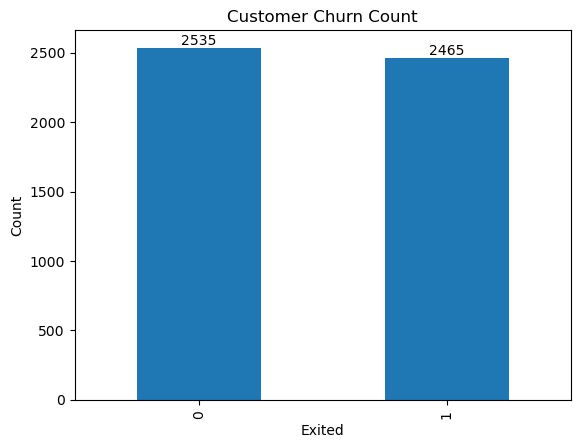

In [17]:
ax=df['Exited'].value_counts().plot(kind='bar')
plt.title("Customer Churn Count")
plt.xlabel("Exited")
plt.ylabel("Count")
ax.bar_label(ax.containers[0])
plt.show()

# EDA

In [18]:
# ploting histogram

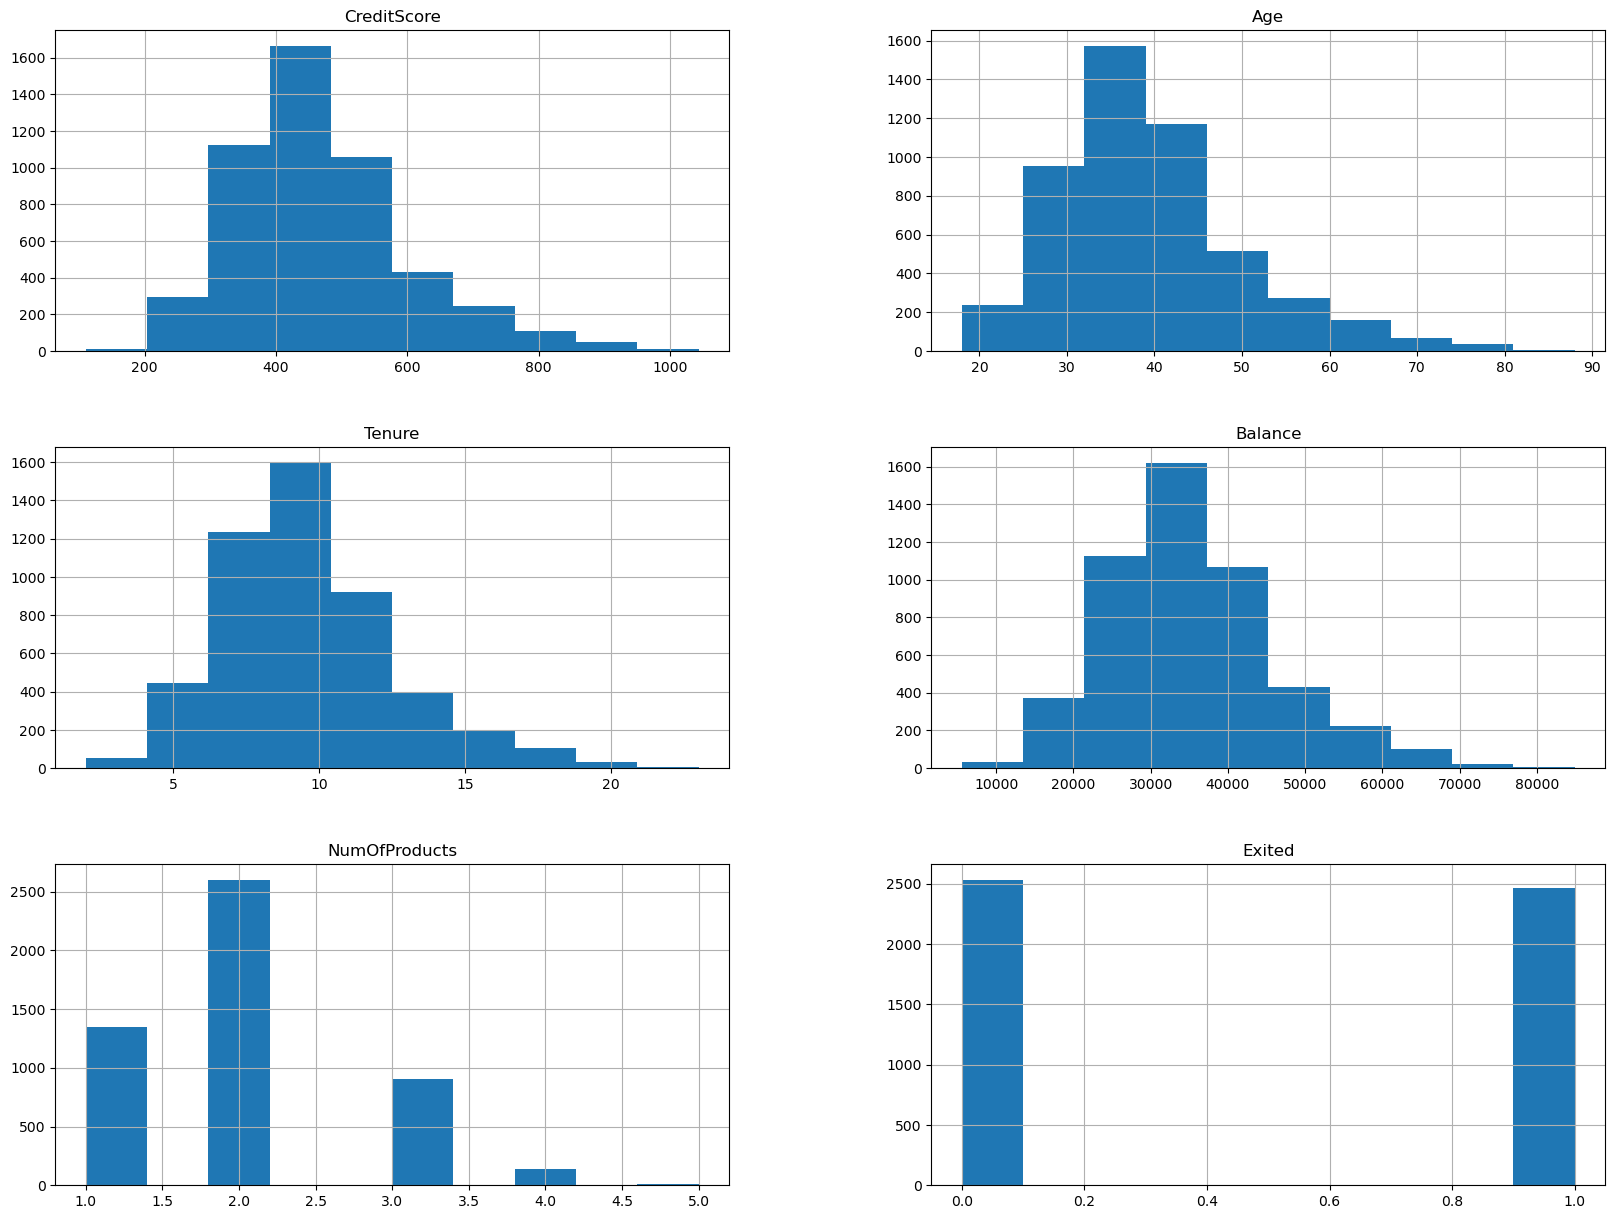

In [19]:
fg=df.select_dtypes(include="number")
fg.hist(figsize=(20,15));
plt.savefig("plt.png")

# OUTLIERS

In [20]:
# Outliers are extreme values that are very different from other data points.

<Axes: >

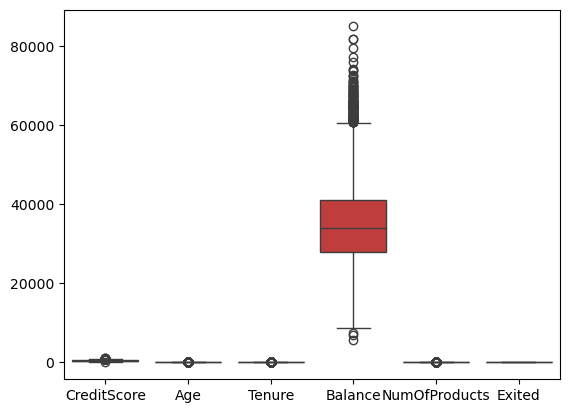

In [21]:
import seaborn as sns
sns.boxplot(df)

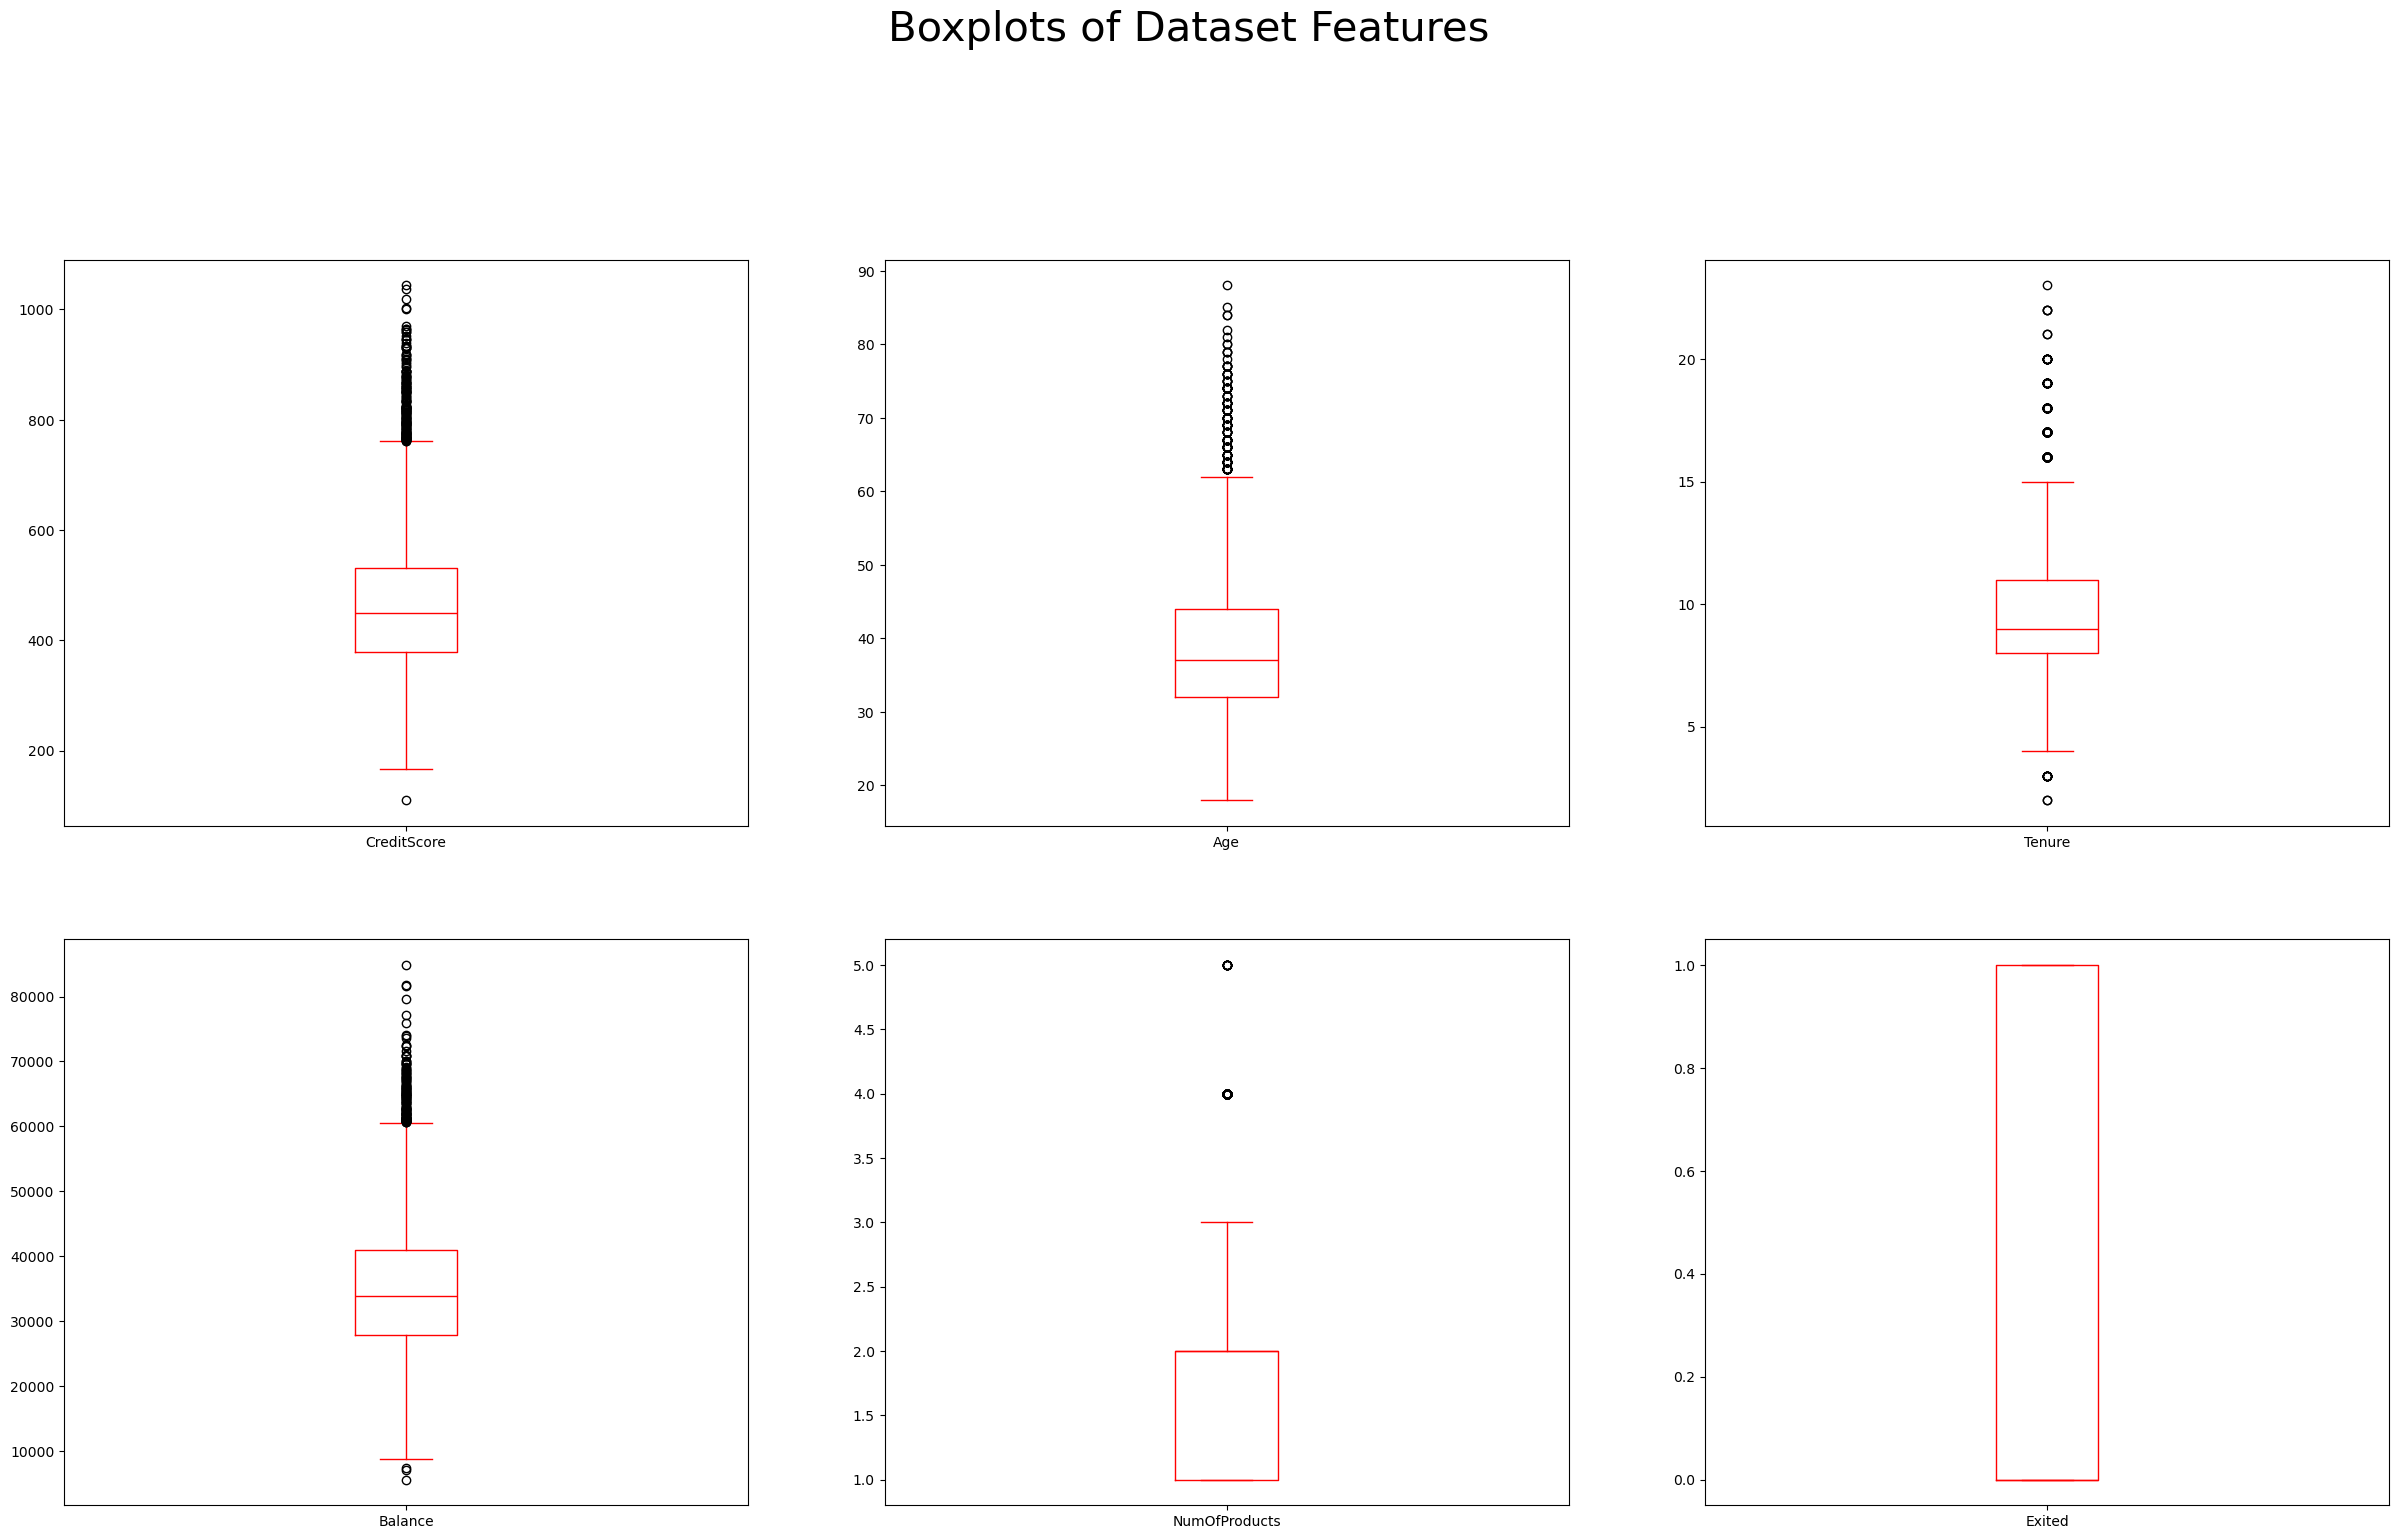

In [22]:
df.plot(kind='box', subplots=True, layout=(3, 3), figsize=(30, 25), color='red')
plt.suptitle('Boxplots of Dataset Features', fontsize=30)
plt.show()

Pair plot

In [23]:
# relationship between all numerical variables in a dataset.

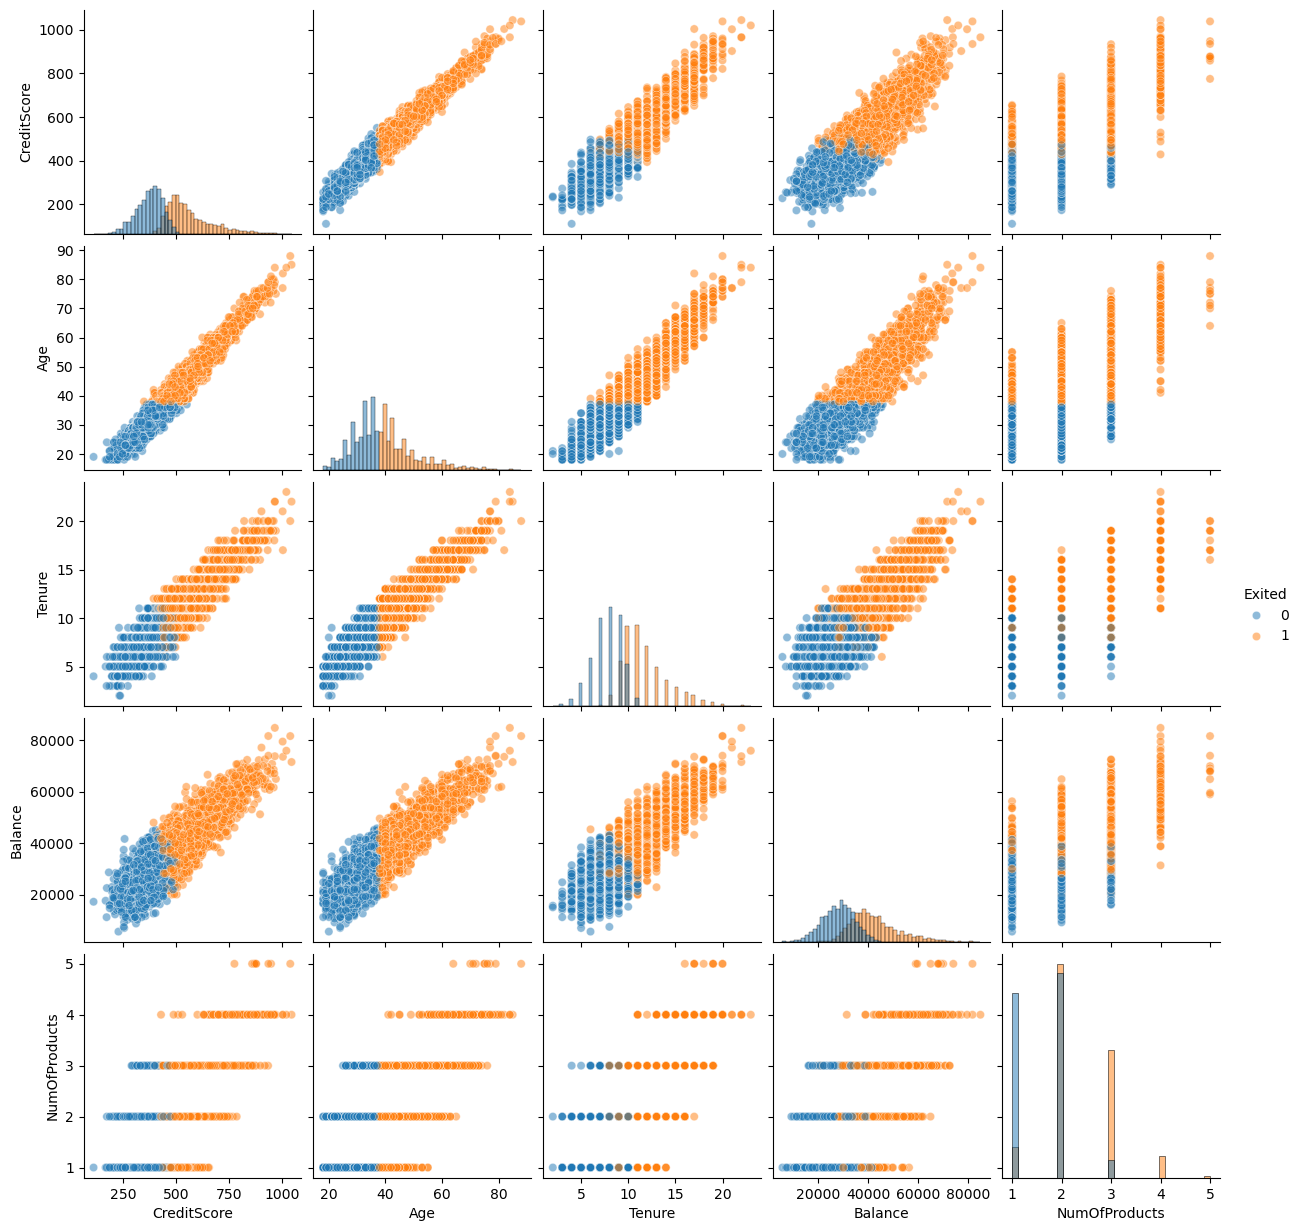

In [24]:
cols=['CreditScore','Geography','Gender','Age','Tenure','Balance','NumOfProducts','Exited']

# Create pair plot
sns.pairplot(df[cols], hue='Exited', diag_kind='hist',plot_kws={"alpha":0.5})

plt.show()

# OUTLIERS TREATMENT

In [25]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'Exited'], dtype='object')

In [26]:
def cap_outliers_iqr(data, columns):
    data_out = data.copy()
    
    for col in columns:
        Q1 = data_out[col].quantile(0.25)
        Q3 = data_out[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        data_out[col] = np.clip(data_out[col], lower, upper)
    
    return data_out

In [27]:
df = cap_outliers_iqr(df, numeric_cols)

<Axes: >

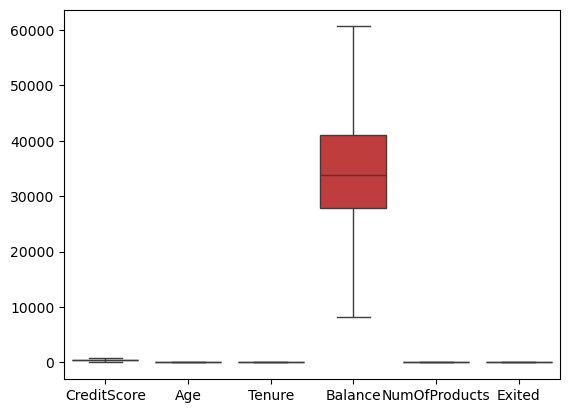

In [28]:
sns.boxplot(df)

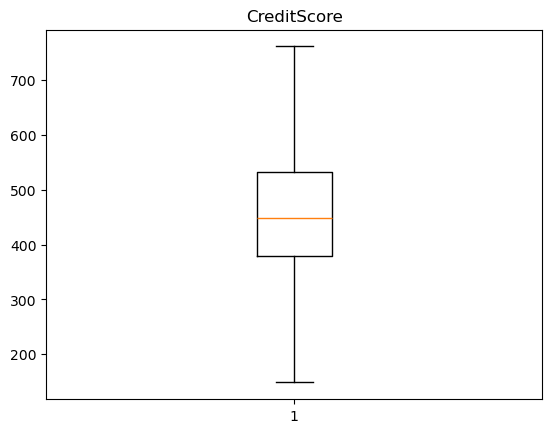

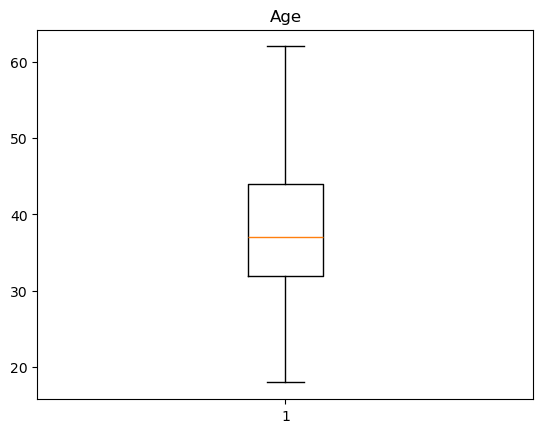

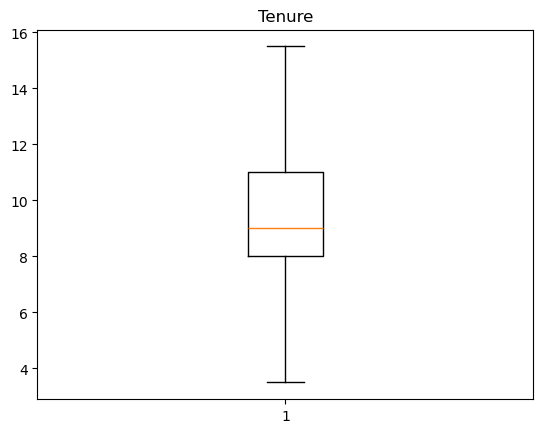

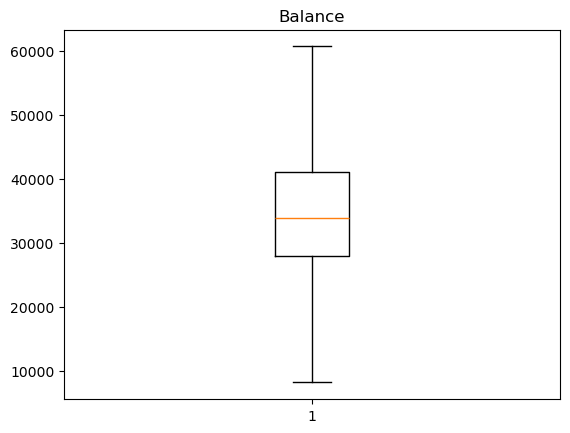

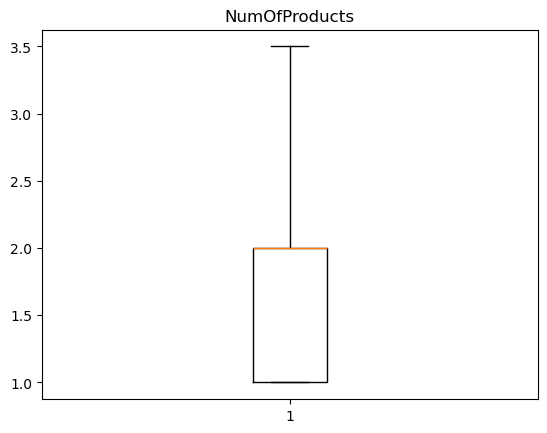

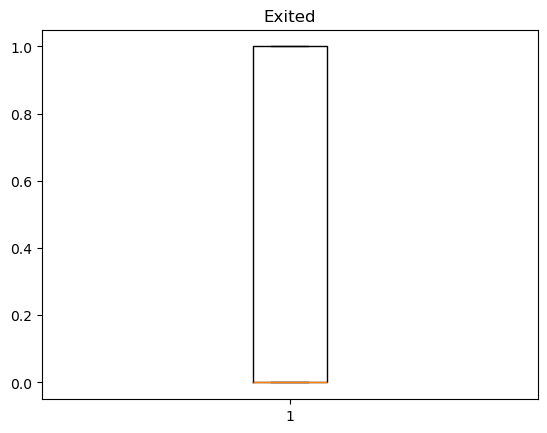

In [29]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'Exited']
for i in numeric_cols:
    plt.figure()
    plt.boxplot(df[i])
    plt.title(i);

# ENCODING

In [30]:
# converting categorical data into numerical format

In [31]:
le1=LabelEncoder()
le2=LabelEncoder()

In [32]:
df['Geography']=le1.fit_transform(df['Geography'])
df['Gender']=le2.fit_transform(df['Gender'])

In [33]:
df.dtypes

CreditScore      float64
Geography          int64
Gender             int64
Age                int64
Tenure           float64
Balance          float64
NumOfProducts    float64
Exited             int64
dtype: object

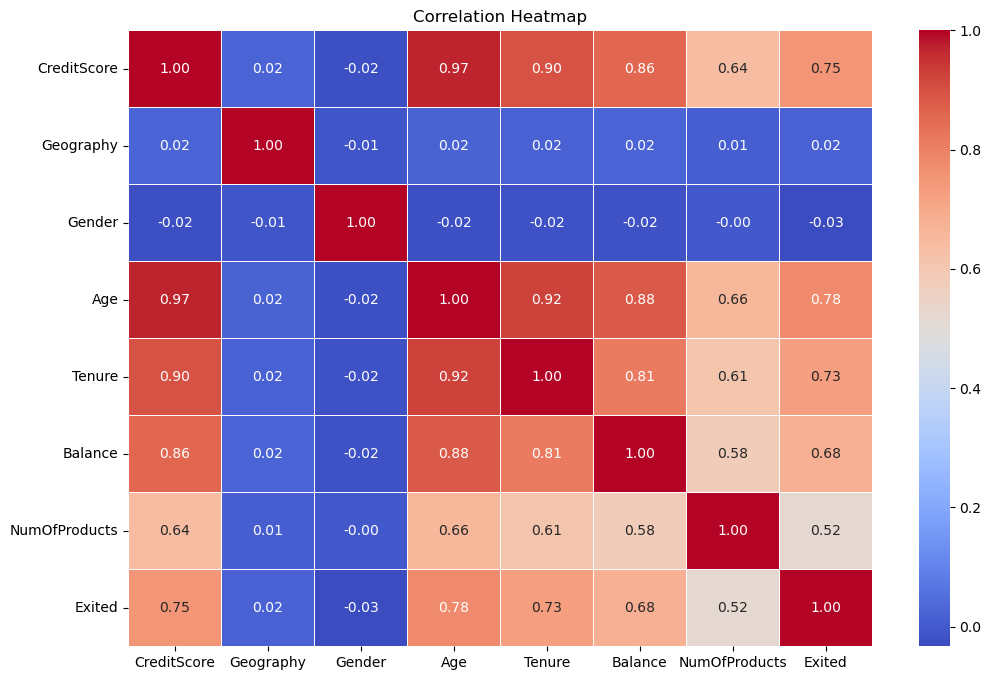

In [34]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [35]:
df.corr()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,Exited
CreditScore,1.000000,0.024787,-0.021377,0.969841,0.896066,0.856086,0.640269,0.752244
Geography,0.024787,1.000000,-0.008786,0.022710,0.015867,0.024175,0.010950,0.019642
Gender,-0.021377,-0.008786,1.000000,-0.022261,-0.017648,-0.018917,-0.002547,-0.032666
Age,0.969841,0.022710,-0.022261,1.000000,0.924197,0.881388,0.660521,0.780045
Tenure,0.896066,0.015867,-0.017648,0.924197,1.000000,0.812831,0.611200,0.726263
Balance,0.856086,0.024175,-0.018917,0.881388,0.812831,1.000000,0.582539,0.679253
NumOfProducts,0.640269,0.010950,-0.002547,0.660521,0.611200,0.582539,1.000000,0.518452
Exited,0.752244,0.019642,-0.032666,0.780045,0.726263,0.679253,0.518452,1.000000


# Split X and Y

In [36]:
x=df.drop('Exited',axis=1)
y=df['Exited']

In [37]:
x

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts
0,491.287210,0,0,42,10.0,40283.570765,2.0
1,478.397577,2,0,41,10.0,36208.678494,2.0
2,450.130705,0,0,42,10.0,41038.442691,2.0
3,458.097294,0,0,39,10.0,42715.149282,2.0
4,537.984872,2,0,43,12.0,37529.233126,2.0
...,...,...,...,...,...,...,...
4995,471.033062,0,0,36,8.0,32155.174846,2.0
4996,468.049651,1,1,44,12.0,43157.052897,3.0
4997,494.840498,2,1,43,12.0,54264.551005,2.0
4998,494.872967,2,0,40,9.0,40040.180947,3.0


In [38]:
y

0       1
1       1
2       1
3       1
4       1
       ..
4995    0
4996    1
4997    1
4998    1
4999    1
Name: Exited, Length: 5000, dtype: int64

# Train Test Split

In [39]:
# Train-test split is the process of dividing data into training and testing sets to evaluate model performance on unseen data.

In [40]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

# SCALING

In [41]:
# Scaling is the process of transforming numerical values into a similar range to improve machine learning model performance

In [42]:
from sklearn.preprocessing import StandardScaler

In [43]:
sc=StandardScaler()
x_train= sc.fit_transform(x_train)
x_test= sc.fit_transform(x_test)

# HYPER PARAMETER TUNING

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import ConfusionMatrixDisplay

**KNeighborsClassifier**

In [45]:
from sklearn.neighbors import KNeighborsClassifier

In [46]:
knn=KNeighborsClassifier()
param_grid = {'n_neighbors': [3,5,27,59,11]} # number of nearby points used for prediction
knt=GridSearchCV(knn,param_grid,cv=10,scoring='accuracy')
knt.fit(x_train, y_train)
print(knt.best_params_)
print(knt.best_score_)

{'n_neighbors': 3}
0.95475


In [47]:
kn_new=KNeighborsClassifier(n_neighbors=3)
kn_new.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=3)

In [74]:
knnt = kn_new.score(x_test,y_test)
knntt = kn_new.score(x_train,y_train)
print('Test accuracy:' ,kn_new.score(x_test,y_test)) 
print('train accuracy:',kn_new.score(x_train,y_train))

Test accuracy: 0.954
train accuracy: 0.97925


***Decision Tree***

In [49]:
from sklearn.tree import DecisionTreeClassifier

In [50]:
dt=DecisionTreeClassifier()
param_grid = {
    'criterion': ['gini', 'entropy'], # it measures how pure the data is after split
    'max_depth': [3, 5, 7, 9] # control how deep the tree can grow 
}

Dtr=GridSearchCV(dt,param_grid,cv=5,scoring='accuracy',n_jobs=-1)
Dtr.fit(x_train, y_train)

print(Dtr.best_params_)
print(Dtr.best_score_)

{'criterion': 'gini', 'max_depth': 3}
1.0


In [51]:
dt_new=DecisionTreeClassifier(criterion='gini',max_depth=3)
dt_new.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3)

In [75]:
dct = dt_new.score(x_test,y_test)
dcst = dt_new.score(x_train,y_train)
print('Test accuracy:' ,dt_new.score(x_test,y_test)) 
print('train accuracy:',dt_new.score(x_train,y_train))

Test accuracy: 0.952
train accuracy: 1.0


**NAIVE BAYES**

In [97]:
from sklearn.naive_bayes import GaussianNB

In [98]:
nb=GaussianNB()
nb_new=GaussianNB()
nb_new.fit(x_train,y_train)

GaussianNB()

In [99]:
nvb = nb_new.score(x_test,y_test)
nvbs = nb_new.score(x_train,y_train)
print('Test accuracy:' ,nb_new.score(x_test,y_test)) 
print('train accuracy:',nb_new.score(x_train,y_train))

Test accuracy: 0.933
train accuracy: 0.94225


**Logistic Regression**

In [58]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
param= {'C': [0.01, 0.1, 1, 10, 100]} # control  regulation strength
Lrn=GridSearchCV(lr,param,cv=10,scoring='accuracy')
Lrn.fit(x_train,y_train)
print(Lrn.best_params_)
print(Lrn.best_score_)

{'C': 10}
1.0


In [59]:
lr_new=LogisticRegression(C=10)
lr_new.fit(x_train,y_train)

LogisticRegression(C=10)

In [76]:
lrsn = lr_new.score(x_test,y_test)
lrssn = lr_new.score(x_train,y_train)
print('Test accuracy:' ,lr_new.score(x_test,y_test)) 
print('train accuracy:',lr_new.score(x_train,y_train))

Test accuracy: 0.957
train accuracy: 1.0


**Random Forest**

In [61]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf=RandomForestClassifier(n_jobs=-1)
param={'n_estimators': [100, 200], # number of trees in the forest
       'max_depth': [10, 20, None], # maximum depth of each tree
       'criterion': ['gini', 'entropy']}  # how the tree measures the best split.
Rft = GridSearchCV(rf,param, cv=5,scoring='accuracy',n_jobs=1  )
Rft.fit(x_train, y_train)
print(Rft.best_params_)
print(Rft.best_score_)

In [ ]:
rf_new=RandomForestClassifier(criterion='gini',max_depth=10,n_estimators=100)
rf_new.fit(x_train,y_train)

In [78]:
rmf = rf_new.score(x_test,y_test)
rmft = rf_new.score(x_train,y_train)
print('Test accuracy:' ,rf_new.score(x_test,y_test)) 
print('train accuracy:',rf_new.score(x_train,y_train))

Test accuracy: 0.952
train accuracy: 1.0


**GradientBoosting**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

In [ ]:
gb=GradientBoostingClassifier()
param={'n_estimators':[100,200],  # number of trees built sequentialy
       'learning_rate':[0.05,0.1],  # controls how much each tree learns
       'subsample':[0.8, 1.0],  # percentage of data used to train each tree
       'max_depth':[3,5,7]}  # control tree comlexxity
gbg=GridSearchCV(gb,param,cv=3,scoring='accuracy',n_jobs=-1)
gbg.fit(x_train, y_train)
print(gbg.best_params_)
print(gbg.best_score_)

In [ ]:
gb_new=GradientBoostingClassifier(learning_rate=0.05,max_depth=3,n_estimators=100,subsample=0.8)
gb_new.fit(x_train,y_train)

In [79]:
gtb = gb_new.score(x_test,y_test)
gtbg = gb_new.score(x_train,y_train)
print('Test accuracy:' ,gb_new.score(x_test,y_test)) 
print('train accuracy:',gb_new.score(x_train,y_train))

Test accuracy: 0.952
train accuracy: 1.0


**AdaBoostClassifier**

In [83]:
from sklearn.ensemble import AdaBoostClassifier

In [84]:
base= DecisionTreeClassifier()
ab=AdaBoostClassifier(estimator=base)
param={'n_estimators':[50,100,200,300], # number of week trees created sequentialy
       'learning_rate':[0.01,0.05,0.1,1], # controls how strongly each tree affects the final prediction 
       'estimator__max_depth':[1, 2, 3]} # control how deep decision tree is.
abc=GridSearchCV(ab,param,cv=3,scoring='accuracy',n_jobs=-1)
abc.fit(x_train, y_train)
print(abc.best_params_)
print(abc.best_score_)

{'estimator__max_depth': 1, 'learning_rate': 0.01, 'n_estimators': 50}
1.0


In [85]:
base_tree=DecisionTreeClassifier(max_depth=1)
ab_new=AdaBoostClassifier(estimator=base_tree, learning_rate=0.01,n_estimators =50)
ab_new.fit(x_train,y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.01)

In [86]:
abt = ab_new.score(x_test,y_test)
abtc = ab_new.score(x_train,y_train)
print('Test accuracy:' ,ab_new.score(x_test,y_test)) 
print('train accuracy:',ab_new.score(x_train,y_train))

Test accuracy: 0.952
train accuracy: 1.0


**XGBClassifier**

In [89]:
import xgboost as xgb
from xgboost import XGBClassifier

In [90]:
xg=XGBClassifier()
param={'n_estimators':[100, 200, 300], # number of trees built sequently
       'max_depth':[3, 5, 7], # muximum depth od each trees
       'learning_rate':[0.01, 0.05, 0.1]} # control how fast thee model learns
xgb=GridSearchCV(xg,param,cv=3,scoring='accuracy',n_jobs=-1)
xgb.fit(x_train, y_train)
print(xgb.best_params_)
print(xgb.best_score_)

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100}
1.0


In [91]:
xg_new=XGBClassifier(learning_rate=0.01,max_depth =3,n_estimators =100)
xg_new.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.01, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [92]:
xgbc = xg_new.score(x_test,y_test)
xgbcr = xg_new.score(x_train,y_train)
print('Test accuracy:' ,xg_new.score(x_test,y_test)) 
print('train accuracy:',xg_new.score(x_train,y_train))

Test accuracy: 0.952
train accuracy: 1.0


**SVM (support vector Machine)**

In [ ]:
SVC is a classification algorithm that finds the optimal hyperplane to separate classes by maximizing the margin between them.

In [93]:
from sklearn.svm import SVC

In [94]:
sv=SVC()
param={'C':[0.1,1,10], # controll over fitting
       'kernel': ['linear', 'poly'], # how data is seperated
       'gamma': ['scale', 0.1, 0.01]} #  how for the influence one data point of eaches
sc=GridSearchCV(sv,param,cv=3,scoring='accuracy',n_jobs=-1)
sc.fit(x_train, y_train)
print(sc.best_params_)
print(sc.best_score_)

{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
1.0


In [95]:
sv_new=SVC(C=10, gamma='scale', kernel='linear')
sv_new.fit(x_train,y_train)

SVC(C=10, kernel='linear')

In [96]:
svc = sv_new.score(x_test,y_test)
svc_cl = sv_new.score(x_train,y_train)
print('Test accuracy:' ,sv_new.score(x_test,y_test)) 
print('train accuracy:',sv_new.score(x_train,y_train))

Test accuracy: 0.952
train accuracy: 1.0


**Ridge**

In [103]:
from sklearn.linear_model import RidgeClassifier
rg = RidgeClassifier()

param = {
    'alpha':[0.1,1,10],     # regularization strength
    'solver':['auto','svd','lsqr']   # algorithm used
}

sc = GridSearchCV(rg, param, cv=3, scoring='accuracy', n_jobs=-1)
sc.fit(x_train, y_train)

print(sc.best_params_)
print(sc.best_score_)

{'alpha': 10, 'solver': 'auto'}
0.9377494298612135


In [104]:
rg_new = RidgeClassifier(alpha=10, solver='auto')
rg_new.fit(x_train, y_train)

RidgeClassifier(alpha=10)

In [105]:
print('Test accuracy:', rg_new.score(x_test, y_test))
print('Train accuracy:', rg_new.score(x_train, y_train))

Test accuracy: 0.908
Train accuracy: 0.93825


In [107]:
rg_train= rg_new.score(x_train,y_train)
rg_test= rg_new.score(x_test,y_test)

Data Frame After Tuning

In [108]:
tb1=pd.DataFrame()
tb1['model']=pd.Series(['logistic','decision tree','random forest','GradientBoosting','KNN','Adaboost','SVC','XGB','Naive bayes','Ridge'])
tb1['test accuracy']=pd.Series([lrsn,dct,rmf,gtb,knnt,abt,svc,xgbc,nvb,rg_test])
tb1['train accuracy']=pd.Series([lrssn,dcst,rmft,gtbg,knntt,abtc,svc_cl,xgbcr,nvbs,rg_train])
tb1

,model,test accuracy,train accuracy
0,logistic,0.957,1.00000
1,decision tree,0.952,1.00000
2,random forest,0.952,1.00000
3,GradientBoosting,0.952,1.00000
4,KNN,0.954,0.97925
5,Adaboost,0.952,1.00000
6,SVC,0.952,1.00000
7,XGB,0.952,1.00000
8,Naive bayes,0.933,0.94225
9,Ridge,0.908,0.93825


# Confusion matrix

In [109]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [110]:
y_pred = nb_new.predict(x_test)

In [111]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[478   4]
 [ 63 455]]


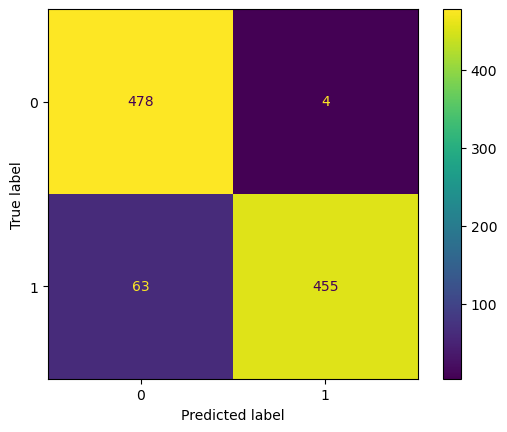

In [112]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

# Classification Report

In [116]:
from sklearn.metrics import classification_report

In [117]:
y_pred = kn_new.predict(x_test)

In [118]:
cr= classification_report(y_test,y_pred)
print(cr)

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       482
           1       0.98      0.93      0.95       518

    accuracy                           0.95      1000
   macro avg       0.95      0.95      0.95      1000
weighted avg       0.96      0.95      0.95      1000



# Deployment

In [71]:
import joblib

In [119]:
joblib.dump(kn_new,"knn_model.pkl")

['knn_model.pkl']